In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("data/Bcard.txt")
data.head()

,obs_mth,bad_ind,uid,td_score,jxl_score,mj_score,rh_score,zzc_score,zcx_score,person_info,finance_info,credit_info,act_info
0,2018-10-31,0.0,A10000005,0.675349,0.144072,0.186899,0.483640,0.928328,0.369644,-0.322581,0.023810,0.00,0.217949
1,2018-07-31,0.0,A1000002,0.825269,0.398688,0.139396,0.843725,0.605194,0.406122,-0.128677,0.023810,0.00,0.423077
2,2018-09-30,0.0,A1000011,0.315406,0.629745,0.535854,0.197392,0.614416,0.320731,0.062660,0.023810,0.10,0.448718
3,2018-07-31,0.0,A10000481,0.002386,0.609360,0.366081,0.342243,0.870006,0.288692,0.078853,0.071429,0.05,0.179487
4,2018-07-31,0.0,A1000069,0.406310,0.405352,0.783015,0.563953,0.715454,0.512554,-0.261014,0.023810,0.00,0.423077


In [3]:
data['obs_mth'].value_counts()

obs_mth
2018-07-31    34030
2018-06-30    20565
2018-11-30    15975
2018-10-31    14527
2018-09-30    10709
Name: count, dtype: int64

In [4]:
data['bad_ind'].value_counts()

bad_ind
0.0    94008
1.0     1798
Name: count, dtype: int64

In [5]:
train = data[data['obs_mth'] != '2018-11-30']
val = data[data['obs_mth'] == '2018-11-30']

In [6]:
feature_list = ['td_score', 'jxl_score', 'mj_score','rh_score', 'zzc_score', 'zcx_score', 'person_info', 'finance_info','credit_info', 'act_info']

In [9]:
x = train[feature_list]
y = train['bad_ind']
val_x = val[feature_list]
val_y = val['bad_ind']

lr_model = LogisticRegression(l1_ratio=1.0, C=1.0, solver='liblinear', max_iter=100, random_state=0)
lr_model.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

Kolmogorov-Smirnov
TPR（True Positive Rate）：累计坏人占比。
FPR（False Positive Rate）：累计好人占比。
KS（Kolmogorov-Smirnov）：KS值 = max(TPR - FPR)
KS 值的取值范围为
<0.2：模型区分能力较差，基本不可用。
0.2-0.3：模型具有一定的区分能力，勉强可用。
0,3-0,4：模型具有较好的区分能力，是金融风控中最理想的区间。
>0,5：模型区分度极高，但也需要警惕是否存在“数据泄露”或过拟合风险

in training set and validation set respectively to evaluate the model performance to check overfit or not.

                    真实标签
                 坏客户(1)   好客户(0)
              ┌────────────┬────────────┐
预测坏客户(1) │    TP      │    FP      │
              │  抓住坏人  │  误杀好人  │
              ├────────────┼────────────┤
预测好客户(0) │    FN      │    TN      │
              │  漏掉坏人  │  放过好人  │
              └────────────┴────────────┘

TPR
1.0 ┤       ●━━━●━━━●━━━●━━━●
    │     ╱                     ↑ 好模型：曲线
0.5 ┤   ╱                    尽量靠近左上角
    │ ╱
0.0 ┤●━━━━━━━━━━━━━━━━━━━━━━━●━━→ FPR
    0.0       0.5              1.0
AUC — ROC 曲线下的面积
1.0	完美模型（实际中不可能）
0.8 ~ 1.0	非常好的模型
0.7 ~ 0.8	较好的模型
0.5 ~ 0.7	一般的模型
0.5	等于随机猜测
< 0.5	比随机还差（预测反了）


In [11]:
# return the bad probability of each sample
y_pred = lr_model.predict_proba(x)[:,1]
fpr, tpr, _ = roc_curve(y, y_pred)
train_ks = abs(tpr - fpr).max()
train_auc = roc_auc_score(y, y_pred)
y_pred_val = lr_model.predict_proba(val_x)[:,1]
fpr_val, tpr_val, _ = roc_curve(val_y, y_pred_val)
val_ks = abs(tpr_val - fpr_val).max()
val_auc = roc_auc_score(val_y, y_pred_val)
print(f"train_ks: {train_ks}, val_ks: {val_ks}")
print(f"train_auc: {train_auc}, val_auc: {val_auc}")

train_ks: 0.4341997316275702, val_ks: 0.4019199503684178
train_auc: 0.7915074719159112, val_auc: 0.7645970083877996


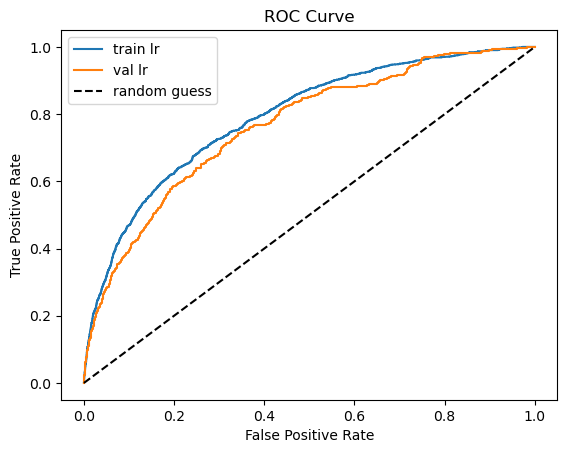

In [14]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("default")
plt.plot(fpr, tpr, label="train lr")
plt.plot(fpr_val, tpr_val, label="val lr")
plt.plot( [0, 1], [0, 1], 'k--', label="random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

(train_ks - val_ks) / train_ks — KS 衰减率
这个公式计算的是 KS 值从训练集到验证集的下降幅度，用来衡量模型的稳定性 / 过拟合程度。
风控行业评判标准
KS 衰减率	模型状态	建议
< 10%	稳定，泛化好	可以直接上线使用
10% ~ 25%	轻度过拟合	可以接受，但建议调参或简化模型
25% ~ 50%	中度过拟合	需要重新调参（调整 C 值、减少特征等）
> 50%	严重过拟合	模型不可用，需要重新设计

In [19]:
(train_ks - val_ks) / train_ks * 100

np.float64(7.434316262277192)

In [20]:
import lightgbm as lgb

In [31]:
train_x, test_x, train_y, test_y = train_test_split(x, y, random_state=42, test_size=0.2)
def lgb_test(train_x, train_y, test_x, test_y):
    clf =lgb.LGBMClassifier(boosting_type = 'gbdt',objective = 'binary',metric = 'auc',
		learning_rate = 0.1,n_estimators = 24,max_depth = 3,num_leaves = 20,
		max_bin = 45,min_data_in_leaf = 6,bagging_fraction = 0.6,bagging_freq = 0,
		feature_fraction = 0.8,
		)
    clf.fit(train_x,train_y,eval_set = [(train_x,train_y),(test_x,test_y)],eval_metric = 'auc')
    return clf,clf.best_score_['valid_1']['auc']

In [32]:
lgb_model, lgb_auc = lgb_test(train_x, train_y, test_x, test_y)

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] bagging_freq is set=0, subsample_freq=0 will be ignored. Current value: bagging_freq=0
[LightGBM] [Info] Number of positive: 1169, number of negative

In [33]:
print(f"LightGBM AUC: {lgb_auc}")

LightGBM AUC: 0.8064916595729881


In [34]:
feat_importance = pd.DataFrame({'feature name':lgb_model.feature_name_,'score important':lgb_model.feature_importances_})

In [35]:
feat_importance

,feature name,score important
0,td_score,3
1,jxl_score,9
2,mj_score,6
3,rh_score,4
4,zzc_score,7
5,zcx_score,5
6,person_info,39
7,finance_info,38
8,credit_info,30
9,act_info,27


In [36]:
feature_list = ['person_info', 'finance_info','credit_info', 'act_info']
x = train[feature_list]
y = train['bad_ind']
val_x = val[feature_list]
val_y = val['bad_ind']

lr_model = LogisticRegression(l1_ratio=0.0, C=1.0, solver='liblinear', max_iter=100, random_state=0)
lr_model.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [37]:
y_pred = lr_model.predict_proba(x)[:, 1]
fpr, tpr, _ = roc_curve(y, y_pred)
train_ks = abs(tpr - fpr).max()
train_auc = roc_auc_score(y, y_pred)
y_pred_val = lr_model.predict_proba(val_x)[:, 1]
fpr_val, tpr_val, _ = roc_curve(val_y, y_pred_val)
val_ks = abs(tpr_val - fpr_val).max()
val_auc = roc_auc_score(val_y, y_pred_val)
print(f"train_ks: {train_ks}, val_ks: {val_ks}")
print(f"train_auc: {train_auc}, val_auc: {val_auc}")

train_ks: 0.4267931595501615, val_ks: 0.4070984151875135
train_auc: 0.7895110124804379, val_auc: 0.7657170898496868


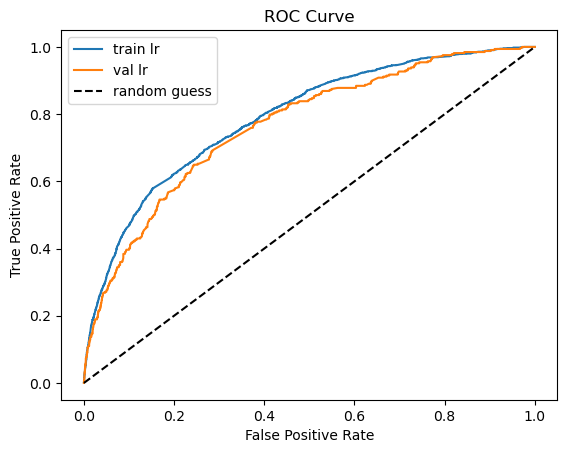

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("default")
plt.plot(fpr, tpr, label="train lr")
plt.plot(fpr_val, tpr_val, label="val lr")
plt.plot([0, 1], [0, 1], 'k--', label="random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

In [40]:
bins = 20
temp_df = pd.DataFrame()
temp_df['bad_rate_predict'] = lr_model.predict_proba(val_x)[:, 1]
temp_df['real_bad'] = val_y.values

In [42]:
temp_df = temp_df.sort_values(by='bad_rate_predict', ascending=False)
temp_df['num'] = [i for i in range(temp_df.shape[0])]
temp_df['num'] = pd.cut(temp_df['num'], bins=bins,  labels=[i for i in range(bins)])
temp_df

,bad_rate_predict,real_bad,num
7935,0.932504,0.0,0
14623,0.892215,1.0,0
14375,0.890397,0.0,0
4280,0.840778,1.0,0
6605,0.828142,0.0,0
...,...,...,...
12821,0.002481,0.0,19
11901,0.002430,0.0,19
11684,0.002381,0.0,19
7081,0.002332,0.0,19


In [44]:
import math
report = pd.DataFrame()
report['BAD'] = temp_df.groupby('num')['real_bad'].sum().astype(int)
report['GOOD'] = temp_df.groupby('num')['real_bad'].count().astype(int) - report['BAD']

report['BAD_CNT'] = report['BAD'].cumsum()
report['GOOD_CNT'] = report['GOOD'].cumsum()

good_total = report['GOOD_CNT'].max()
bad_total = report['BAD_CNT'].max()

report['BAD_PCTG'] = round(report['BAD_CNT'] / bad_total, 3)
report['GOOD_PCTG'] = round(report['GOOD_CNT'] / good_total, 3)
report['BAD_RATE'] = report.apply(lambda x: round(x['BAD'] / (x['BAD'] + x['GOOD']), 3) , axis=1)

def cal_ks(x):
    ks = (x['BAD_CNT'] / bad_total - x['GOOD_CNT'] /	good_total) * 100
    return round(math.fabs(ks), 3)


report['ks'] = report.apply(cal_ks, axis=1)
print(report)

     BAD  GOOD  BAD_CNT  GOOD_CNT  BAD_PCTG  GOOD_PCTG  BAD_RATE      ks
num                                                                     
0     88   711       88       711     0.268      0.045     0.110  22.285
1     42   757      130      1468     0.396      0.094     0.053  30.252
2     28   771      158      2239     0.482      0.143     0.035  33.861
3     30   768      188      3007     0.573      0.192     0.038  38.099
4     24   775      212      3782     0.646      0.242     0.030  40.463
5     19   780      231      4562     0.704      0.292     0.024  41.271
6      9   789      240      5351     0.732      0.342     0.011  38.972
7     15   784      255      6135     0.777      0.392     0.019  38.535
8     12   787      267      6922     0.814      0.442     0.015  37.164
9      8   791      275      7713     0.838      0.493     0.010  34.548
10    10   788      285      8501     0.869      0.543     0.013  32.560
11     3   796      288      9297     0.878      0.

In [60]:
from pyecharts.charts import *
from pyecharts import options as opts
from pylab import *
# mpl.rcParams['font.sans-serif'] = ['SimHei']
np.set_printoptions(suppress=True)
pd.set_option('display.unicode.ambiguous_as_wide', True)
# pd.set_option('display.unicode.east_asian_width', True)
myks = (Line()
	.add_xaxis(report.index.values.tolist())
	.add_yaxis("group bad ration",list(report.BAD_RATE),yaxis_index=0,color="red",
	)
	.set_global_opts(title_opts=opts.TitleOpts(title="roc curve"),	)
	.extend_axis(
		yaxis=opts.AxisOpts(name="ks value",type_="value",min_=0,max_=0.5,position="right",
		axisline_opts=opts.AxisLineOpts(linestyle_opts=opts.LineStyleOpts(color="red")),
		axislabel_opts=opts.LabelOpts(formatter="{value}"),
		))
	.add_yaxis("ks",list(report['ks']),yaxis_index=1,color="blue",label_opts=opts.LabelOpts(is_show=False),
	)
)

myks.render("myks.html")

'F:\\6个月\\the road to machine learning\\1-financial risk management project\\myks.html'

In [47]:
lr_model.coef_.tolist()[0]

[3.215555274317489, 8.232476431717592, 1.6725166500420505, -1.6149426131362816]

In [48]:
lr_model.intercept_

array([-4.05804721])

In [49]:
coef = lr_model.coef_.tolist()[0]
def score(x):
    lr_result = x.person_info*coef[0] + x.finance_info*coef[1] + x.credit_info*coef[2] + x.act_info*coef[3]
    score = 600 + 50*lr_result/math.log(2)
    return score

In [51]:
val['score'] = val.apply(score, axis=1)

In [52]:
val['score'].describe()

count    15975.000000
mean       599.534772
std         62.810891
min        454.185736
25%        551.994393
50%        604.777373
75%        628.072527
max       1082.137990
Name: score, dtype: float64

In [53]:
fpr, tpr, thresholds = roc_curve(val_y, val['score'])
val_ks = abs(tpr - fpr).max()
val_ks

np.float64(0.4070984151875135)